Capbale of performing linear or nonlinear classification. 

### linear SVM Classification

You can think of an SVM as far away from the closest training instances as possible. You can think of an SVM classifier as fitting the widest possible street (represented by the parallel dashed lines) between the classes. This is called large margin classification. 


SVM are sensitive to the feature scales. 

If we stricly impose that all instance be off the street and on the right side. this is called **hard margin classifiaction**. 

There are two main issue with **hard margin** 
- Work only on linearly separable data
- sensitive to outliers. 

Here something missing but 

In Sckit-Learn's SVM classes, you can control this balance using the C hyperparameter. 

A smaller C value leads to a wider street but more margin violation 

If your SVM model is overfitting, you can try regularizing it by reducing C. 

The following Scikkit-Learn loads the iris dataset, Scale the features, and then trains a linear SVM model (Using the LinearSVC class with C = 0.1 and the the hinge loss function)

In [8]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # Iris-Virginica

svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)),
    ])

svm_clf.fit(X, y)

,steps,"[('scaler', ...), ('linear_svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001


In [9]:
svm_clf.predict([[5.5, 1.7]])

array([1.])

Unlike Logistic Regression classification, SVM classifier do not output probabilities for each class. 

In SVM working with large dataset. 

Recommeded option is SGDClassifier class 

SGDClassifier (loss = 'hinge', alpha = 1/ (m * C))

This is regular Stochastic Gradient Descent to train a liner SVM classifier. 

It does not converge as fast as the LinearSVC class, but it can be useful to handle huge dataset that do not fit in memory (using out of core training technique)

### Nonlinear SVM Classification 

One approach to handling nonlinear datasets is to add more features. 

To implement this idea using Sckikit-Learn, you can crate a Pipeline containing a PolynomialFeatures transformer. 

In [10]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures



In [11]:
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

In [34]:
X.min()

-1.2720155884887554

In [28]:
X[:, 0][y==0], X[:, 1][y==0]

(array([-1.10174514, -0.72871455, -0.65891281,  0.22828266,  0.87158283,
         0.88304472,  0.38220326, -0.32279169, -0.63569974,  1.21073294,
         0.49598571, -0.26038715,  0.03146515, -1.03151461,  0.40767679,
        -0.9379972 ,  0.73867736,  0.92445501, -1.05805492, -0.17181754,
         0.8346617 , -0.6303002 ,  0.59525613, -0.99578508, -0.45366574,
         0.73645602, -0.26764459,  0.32384572,  0.14332957,  0.51814426,
        -0.22452786,  1.131632  ,  0.3723287 , -0.63902305,  0.82849531,
         1.01195087, -0.64970203, -1.12470228, -1.27201559, -0.78027235,
        -0.94748558, -0.29808882, -0.81839086, -0.18600799,  0.82045555,
         0.23277362,  1.27522216, -0.04098885,  0.53409306,  0.51358597]),
 array([ 0.23685641,  0.14652347,  0.857088  ,  0.73453868,  0.70852888,
        -0.12658445,  0.76957897,  0.92145523,  0.91873422,  0.37721455,
         0.66135542,  0.88295876,  0.79868048,  0.35788726,  0.9574049 ,
         0.46846678,  0.52356398,  0.79897643,  0

In [14]:
y[0]

1

In [23]:
X[0][y==0]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 2 but corresponding boolean dimension is 100

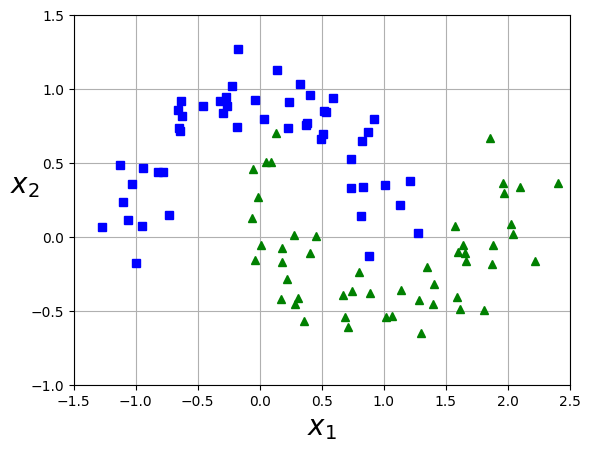

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

In [44]:
polynomial_svm_clf = Pipeline([
        ("poly_features", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        ("svm_clf", LinearSVC(C=10, loss="hinge", random_state=42))
    ])

polynomial_svm_clf.fit(X, y)

/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,steps,"[('poly_features', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [ ]:
polynomial_svm_clf.decision_function

In [ ]:
axes = [-1.5, 2.5, -1, 1.5]
x0s = np.linspace(axes[0], axes[1], 100)
x1s = np.linspace(axes[2], axes[3], 100)
x0, x1 = np.meshgrid(x0s, x1s)


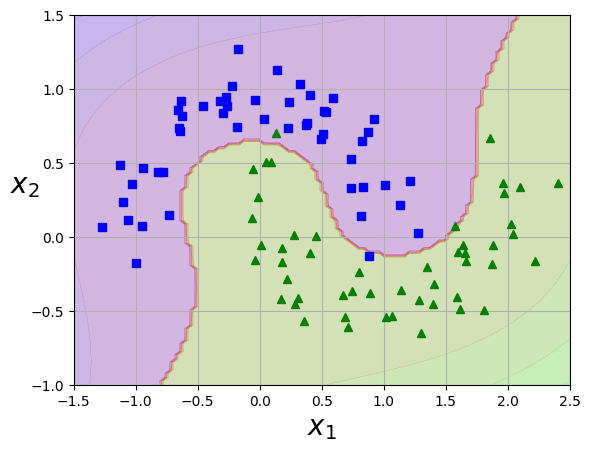

In [46]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

plt.show()

Adding polynomial features is simple to implement and can work great with all sorts of Machine Learning algorithms but at low polynomial degree it cannot deal with very complex datasets, and a high polynomial degree it creates a huge number of features, making the model too slow. 

In [47]:
from sklearn.svm import SVC
poly_kernel_svm_clf = Pipeline((
    ('scaler', StandardScaler()), 
    ('svm_clf', SVC(kernel='poly', degree=3, coef0=1, C=5))
))

poly_kernel_svm_clf.fit(X, y)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,5
,kernel,'poly'
,degree,3
,gamma,'scale'


In [48]:
poly100_kernel_svm_clf = Pipeline((
    ('scaler', StandardScaler()), 
    ('svm_clf', SVC(kernel="poly", degree=10, coef0=100, C=5))
))

poly100_kernel_svm_clf.fit(X, y)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,5
,kernel,'poly'
,degree,10
,gamma,'scale'


Text(0.5, 1.0, '$d=3, r=1, C=5$')

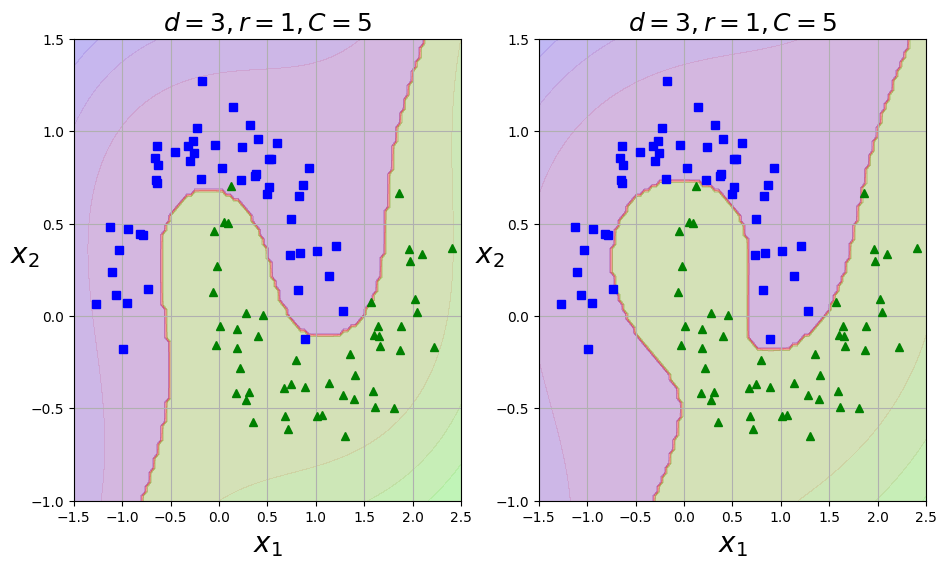

In [57]:
plt.figure(figsize=(11, 6))

plt.subplot(121)
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"$d=3, r=1, C=5$", fontsize=18)

plt.subplot(122)
plot_predictions(poly100_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"$d=3, r=1, C=5$", fontsize=18)

### Regression 


In [58]:
np.random.seed(42)
m = 50
X = 2 * np.random.rand(m, 1)
y = (4 + 3 * X + np.random.randn(m, 1)).ravel()

In [59]:
from sklearn.svm import LinearSVR

svm_reg = LinearSVR(epsilon=1.5, random_state=42)
svm_reg.fit(X, y)

,epsilon,1.5
,tol,0.0001
,C,1.0
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,42
,max_iter,1000
